In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import shelve
import string
import numba as nb
import timeit
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib import colors
from scipy.stats import cauchy

In [2]:
@nb.njit()
def frk4_step(y,u0,umid,u1,h,w,K,F,N):
    k1 = h * Fkuramoto_nb( y, u0,w,K,F,N)
    k2 = h * Fkuramoto_nb(y + 0.5 * k1, umid,w,K,F,N)
    k3 = h * Fkuramoto_nb( y + 0.5 * k2, umid,w,K,F,N)
    k4 = h * Fkuramoto_nb(y + k3, u1, w,K,F,N)
    y = y + (1.0 / 6.0)*(k1 + 2 * k2 + 2 * k3 + k4)
    return ((y) % (2*math.pi))

@nb.njit()
def Fkuramoto_nb(x,ut,w,K,F,N):
    y = np.empty((x.shape[0]),dtype='float64')
    R1=0
    R2=0
    for i in nb.prange(x.shape[0]):
        R1 +=np.cos(x[i])
        R2 +=np.sin(x[i])   
    for i in nb.prange(x.shape[0]):
        y[i] = w[i] - K*R1*np.sin(x[i])/N + K*R2*np.cos(x[i])/N +  F* np.sin(ut[i]-x[i])
    return y




@nb.njit()
def whipeout(N, initlen, ut0,utmid,ut1, x0, h,w,p):
    K,F= p[0], p[1]
    rwipe = np.zeros(initlen)
    psiwipe = np.zeros(initlen)
    for j in nb.prange(initlen):
        x  = frk4_step(x0,ut0[:,j],utmid[:,j],ut1[:,j],h,w,K,F,N)
        x0 = x 
        rwipe[j]= np.sqrt((np.cos(x0).sum())**2+(np.sin(x0).sum())**2)/N
        psiwipe[j] =  np.angle(np.cos(x0).mean() + 1j*np.sin(x0).mean())
    return x, rwipe,psiwipe

@nb.njit()
def kura_run(N,runlen, ut0, utmid,ut1, x0, h,w,p):
    K,F = p[0], p[1]
    X = np.empty((N,runlen))
    for j in nb.prange(runlen):
        x  = frk4_step(x0,ut0[:,j],utmid[:,j],ut1[:,j],h,w,K,F,N)
        x0 = x
        X[:,j] = x
    return X

@nb.njit()
def frk4closed_step(y,p,pvec,Wout,w,h,N):
    k1 = h * fkura_closed( y,p,pvec,Wout,w,N)
    k2 = h * fkura_closed(y + 0.5 * k1, p,pvec,Wout,w,N)
    k3 = h * fkura_closed( y + 0.5 * k2, p,pvec,Wout,w,N)
    k4 = h * fkura_closed(y + k3, p,pvec,Wout,w,N)
    y = y + (1.0 / 6.0)*(k1 + 2 * k2 + 2 * k3 + k4)
    return ((y) % (2*math.pi))
    
@nb.njit()
def fkura_closed(x,p,pvec,Wout,w,N):
    
    K,F = p[0],p[1]
    
    y = np.empty(N,dtype='float64')
    R1=0
    R2=0
    
    Up0=  nb_concatdot30( Wout, x)
    
    for i in nb.prange(N):
        R2 +=np.cos(x[i])
        R1 +=np.sin(x[i])   
    for i in nb.prange(N):
        y[i] = w[i] - K*R2*np.sin(x[i])/N + K*R1*np.cos(x[i])/N +  F* np.sin(Up0[pvec[i]]-x[i])

    return y


@nb.njit()
def nb_concatdot30( x, y): 
    res = np.zeros(2,dtype = 'float64')
    Ny = y.shape[0]
    for i in nb.prange(x.shape[1]):
        if i==0:
            res[0]+=x[0,i]
            res[1]+=x[1,i]
        elif i<= Ny:
            res[0]+=x[0,i]*np.sin(y[i-1]) 
            res[1]+=x[1,i]*np.sin(y[i-1])
    return res





@nb.njit()
def kura_test(N,testlen, Wout,x0, h,w,p, pvec):
    X = np.empty((N, testlen))
    Upred = np.empty((2,testlen))
    complex_order =  np.empty((2,testlen))
    complex_order_even =  np.empty((2,testlen))
    complex_order_odd =  np.empty((2,testlen))

    for j in nb.prange(testlen):
        x  =frk4closed_step(x0,p,pvec, Wout,w,h,N)
        X[:,j] = x
        Upred[:,j] = nb_concatdot30(Wout, x)
        x0= x
        #Psipred[j] = np.angle(np.cos(x).mean() + 1j*np.sin(x).mean())
        #rpred[j] =  np.sqrt((np.cos(x).sum())**2+(np.sin(x).sum())**2)/N
        #rpred_even[j] = 2* np.sqrt((np.cos(x[::2]).sum())**2+(np.sin(x[::2]).sum())**2)/N
        #rpred_odd[j] = 2* np.sqrt((np.cos(x[1::2]).sum())**2+(np.sin(x[1::2]).sum())**2)/N
    return X, Upred

@nb.njit()
def NMSE(yeval,ydata):
    
    nmse = 0
    for i in nb.prange(yeval.shape[0]):
        nmse += ( (ydata[i]-yeval[i]) )**2
    nmse=nmse/numba_norm(ydata)**2
    return nmse

@nb.njit() 
def numba_norm(a):
    n = a.shape[0]
    norm = 0
    for i in range(n):
        norm += a[i] * a[i]
    return np.sqrt(norm)


In [3]:
h=0.005
per_freq= 1 #np.sqrt(2)#np.sqrt(2)
utest = np.zeros((50_000,2))
for i in range(50_000):
    utest[i,0] = np.sin( (h*i*per_freq) % (2*np.pi))/10
    utest[i,1] = np.cos( (i*h*per_freq) % (2*np.pi))/10

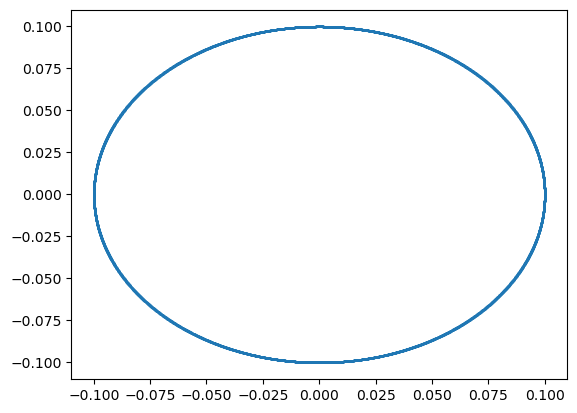

In [4]:
plt.plot(utest[:10_000,0],utest[:10_000,1],'.',markersize=1)

In [5]:
np.random.seed(seed=42)

K=10
F=50

N=2_000
initlen=5_000
trainlen=5_000
p=np.zeros(2)
p[0] = K
p[1] = F
w0=0
w = cauchy(loc=w0,scale=0.01).rvs(size=N)

pvec=np.zeros(N)
for i in range(0,N,2):
    pvec[i] =int(1)
pvec=pvec.astype(int)
#pvec=np.random.choice(2, N)

ut0 =np.eye(2)[pvec] @ utest.T
utmid =np.eye(2)[pvec] @ utest.T
ut1 =np.eye(2)[pvec] @  utest.T


x0int = np.random.rand(N)*2*np.pi #np.linspace(0,2*math.pi,N+1)[:-1]
reg= 1e-4

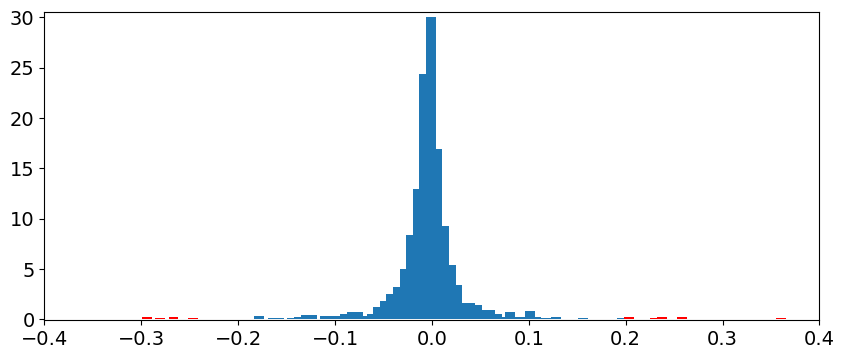

In [6]:
plt.figure(figsize=(10,4))
w_hist, w_bins = np.histogram(w-w0, bins=1800,density=True)
plt.bar(w_bins[:-1][np.abs(w_bins[:-1])<0.2],w_hist[np.abs(w_bins[:-1])<0.2],width=0.01)
plt.bar(w_bins[:-1][np.abs(w_bins[:-1])>=0.2],w_hist[np.abs(w_bins[:-1])>=0.2],width=0.01, color='red')
plt.xlim([-0.4,0.4])
plt.ylim([-0.08,30.5])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/distri.jpg',dpi=400,bbox_inches = 'tight')

In [63]:
h=0.005
x,rwipe,psiwipe=whipeout(N,initlen, ut0,utmid,ut1, x0int, h, w,p)
X0= kura_run(N,trainlen, ut0[:,initlen:],utmid[:,initlen:],ut1[:,initlen:], x,h,w,p)
X =  np.concatenate((np.expand_dims(np.ones(X0.shape[1]),axis=0),np.sin(X0)),axis=0)
Yt = utest[(initlen):(initlen+trainlen),:]
Wout = np.linalg.solve( np.dot(X,X.T) + reg*np.eye(N+1) , np.dot(X,Yt) ).T

In [64]:
pred = (Wout @ X)

(0.098, 0.103)

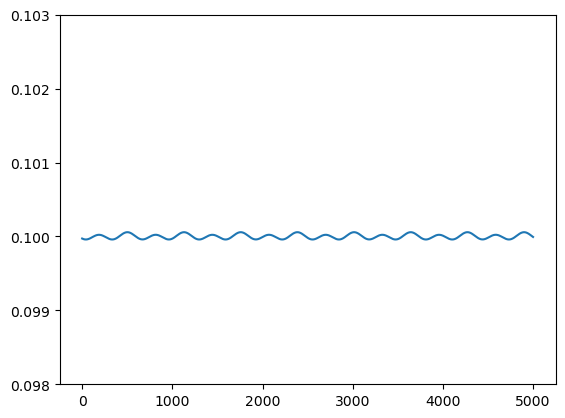

In [65]:
# plt.plot(pred[0,:], pred[1,:],'.')
# plt.show()
plt.plot(np.sqrt(pred[0,:]**2+ pred[1,:]**2))
plt.ylim([0.098,0.103])


In [66]:
x0= X0[:,-1] 
X, Upred = kura_test(N,10_000, Wout,x0, h,w,p,pvec)

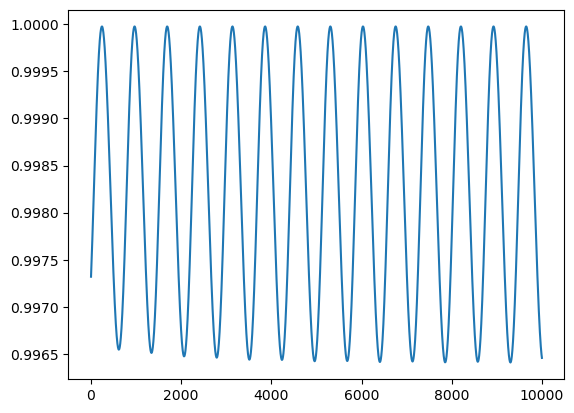

In [67]:
plt.plot((np.sin(X).mean(axis=0))**2+(np.cos(X).mean(axis=0))**2)

In [68]:
X.shape

(2000, 10000)

In [69]:
c_even = np.zeros((2,X.shape[1]))
c_odd = np.zeros((2,X.shape[1]))
c_even[0,:] = (np.cos(X[::2,:]).mean(axis=0))
c_even[1,:] = (np.sin(X[::2,:]).mean(axis=0))
c_odd[0,:] = (np.cos(X[1::2,:]).mean(axis=0))
c_odd[1,:] = (np.sin(X[1::2,:]).mean(axis=0))

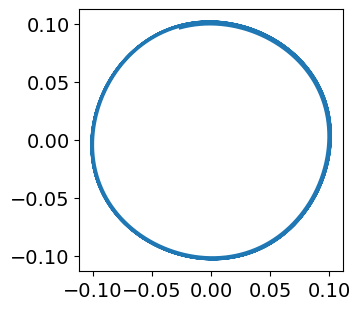

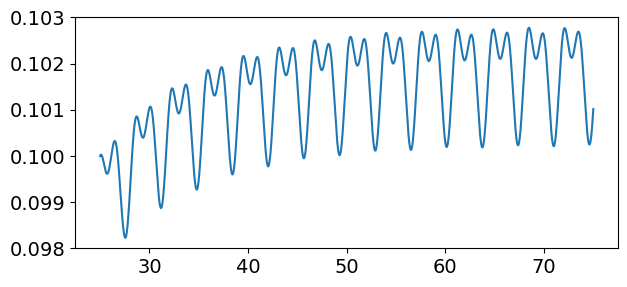

In [70]:
Tvec= np.arange(10_000,10_000+Upred.shape[1])*h

plt.figure(figsize=(3.4,3.4))
plt.plot(Upred[0,:], Upred[1,:])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/predu_circ.jpg',dpi=400,bbox_inches = 'tight')
plt.show()
plt.figure(figsize=(7,3))
plt.plot(Tvec-25, np.sqrt(Upred[0,:]**2+ Upred[1,:]**2))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/predr_circ.jpg',dpi=400,bbox_inches = 'tight')
#print(max(np.sqrt(Upred[0,:]**2+ Upred[1,:]**2)[-2000:]) - min(np.sqrt(Upred[0,:]**2+ Upred[1,:]**2)[-2000:]))

(0.0, 1.5)

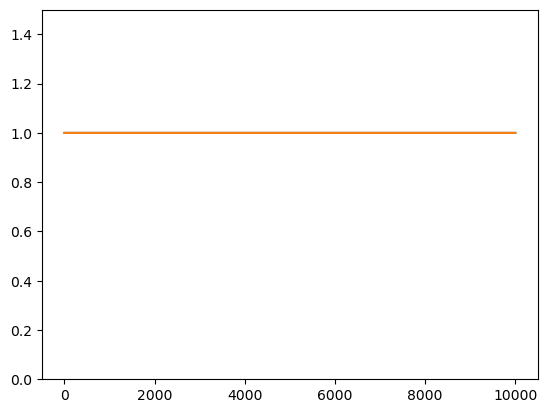

In [71]:
plt.plot(np.sqrt((c_odd[0,:])**2+ (c_odd[1,:])**2))
plt.plot(np.sqrt((c_even[0,:])**2+ (c_even[1,:])**2))
#plt.plot(np.sqrt(((c_even[0,:]+c_odd[0,:])/2)*2+ ((c_even[0,:]+c_odd[1,:])/2)*2))
plt.ylim([0,1.5])

In [72]:
#np.where(Wout[1,1:] == max(Wout[1,1:]))
W0tail = []
W1tail = []
ind0tail = []
ind1tail = []
pos_tail = np.where(np.abs(w-w0)>0.2)
for j in pos_tail[0]:
    if (j % 2) == 0:
        W0tail.append(Wout[1,j+1])
        ind0tail.append(j+1)
    else:
        W1tail.append(Wout[0,j+1])
        ind1tail.append(j+1)
#plt.bar(np.arange(0,pos_tail[0].shape[0],1),Wout[0,1+pos_tail[0]])
#plt.plot(Wout[1,1+pos_tail[0]])


In [73]:
Wout.shape

(2, 2001)

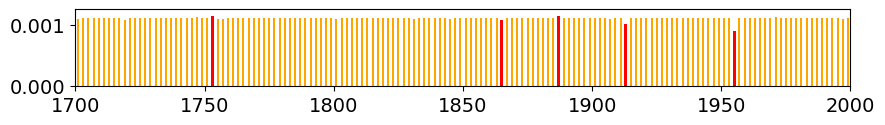

In [74]:
plt.figure(figsize=(10,1))
plt.bar(np.arange(1,Wout.shape[1],2), Wout[1,1::2],color='orange')
plt.bar(ind0tail, Wout[1,:][ind0tail],width=1,color='red')
plt.xlim([1700,2000])
#plt.ylim([-0.02,0.01])

plt.ylim([0,0.00125])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/W1_tail.jpg',dpi=400,bbox_inches = 'tight')

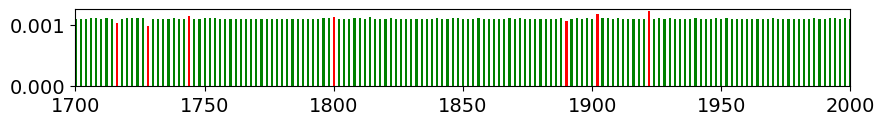

In [75]:
plt.figure(figsize=(10,1))
plt.bar(np.arange(2,Wout.shape[1],2), Wout[0,2::2],color='green')
plt.bar(ind1tail, Wout[0,:][ind1tail],width=1,color='red')
plt.xlim([1700,2000])
#plt.ylim([-0.01,0.01])
plt.ylim([0,0.00125])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/W0_tail.jpg',dpi=400,bbox_inches = 'tight')

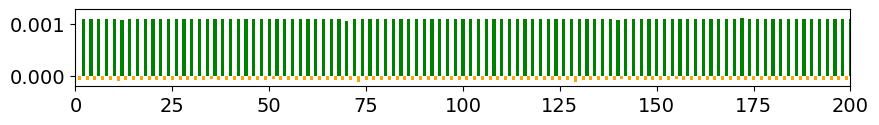

In [76]:
plt.figure(figsize=(10,1))
plt.bar(np.arange(1,Wout.shape[1],2), Wout[0,1::2],color='orange')
plt.bar(np.arange(2,Wout.shape[1],2), Wout[0,2::2],color='green')
plt.xlim([0,200])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/W0.jpg',dpi=400,bbox_inches = 'tight')

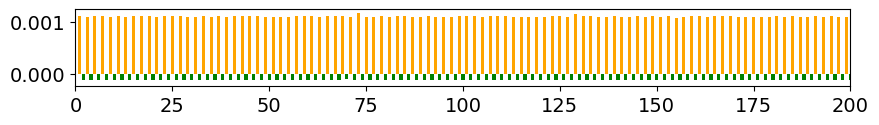

In [77]:
plt.figure(figsize=(10,1))
plt.bar(np.arange(1,Wout.shape[1],2), Wout[1,1::2],color='orange')
plt.bar(np.arange(2,Wout.shape[1],2), Wout[1,2::2],color='green')
plt.xlim([0,200])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/W1.jpg',dpi=400,bbox_inches = 'tight')

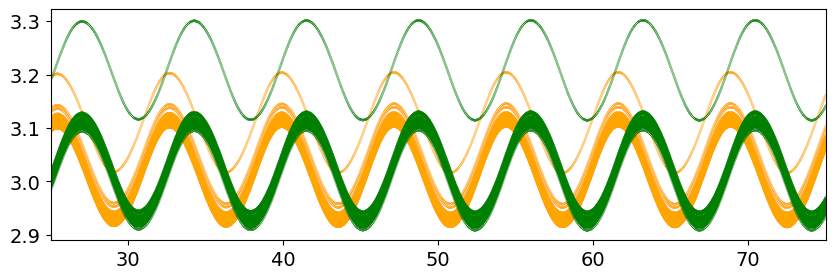

In [52]:
plt.figure(figsize=(10,3))
plt.plot(np.arange(10_000,20_000)*h-25,(X[::2,:].T + 3) % (2*np.pi),'.',markersize=0.1,color='orange');
plt.plot(np.arange(10_000,20_000)*h-25,(X[1::2,:].T + 3) % (2*np.pi),'.',markersize=0.1,color='green');

plt.xlim([25,75])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/X.jpg',dpi=400,bbox_inches = 'tight')

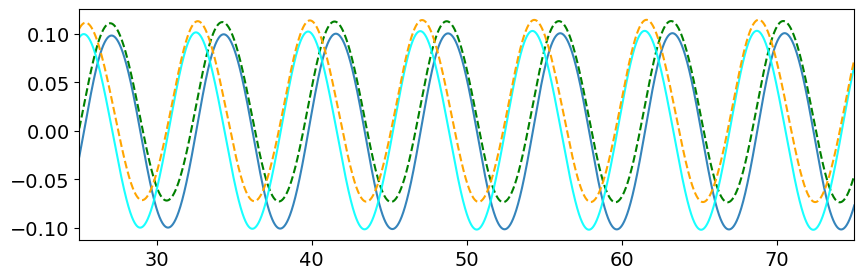

In [53]:
plt.figure(figsize=(10,3))
psi_angle = [np.angle(complex(c0,c1)) for c0,c1 in zip(c_odd[0,:], c_odd[1,:])]
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h-25,Upred[0,:], alpha=0.9)
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h-25,np.sin(psi_angle),'--', color='green')


psi_angle = [np.angle(complex(c0,c1)) for c0,c1 in zip(c_even[0,:], c_even[1,:])]
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h-25,Upred[1,:],color='cyan', alpha=0.9)
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h-25,np.sin(psi_angle),'--', color='orange')

plt.xlim([25,75])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'Pictures_paper/predUandpsi.jpg',dpi=400,bbox_inches = 'tight')

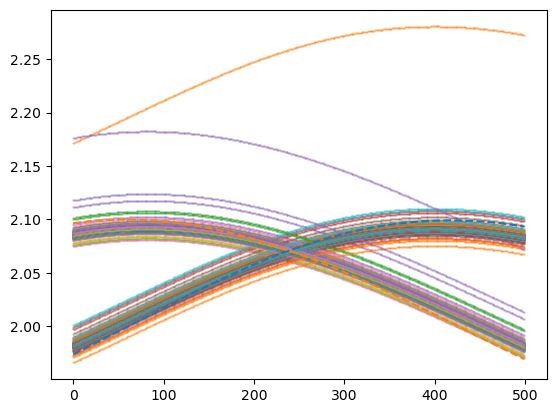

In [252]:
plt.plot((X[:,:500].T+ 2) % (2*np.pi),'.',alpha=0.5, markersize=1)
plt.plot(Upred[0,:500]+2, '--')
plt.plot(Upred[1,:500]+2,'--')

In [253]:
np.where((((X[:,:500].T+ 2) % (2*np.pi))>2.2).sum(axis=0))

(array([531], dtype=int64),)

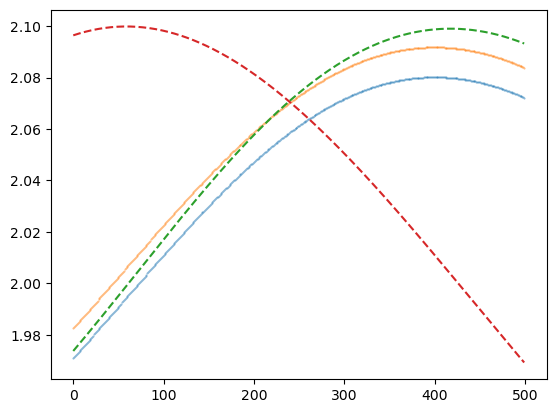

In [254]:
plt.plot((X[821,:500].T+ 2) % (2*np.pi),'.',alpha=0.5, markersize=1)
plt.plot((X[619,:500].T+ 2) % (2*np.pi),'.',alpha=0.5, markersize=1)
plt.plot(Upred[0,:500]+2, '--')
plt.plot(Upred[1,:500]+2,'--')

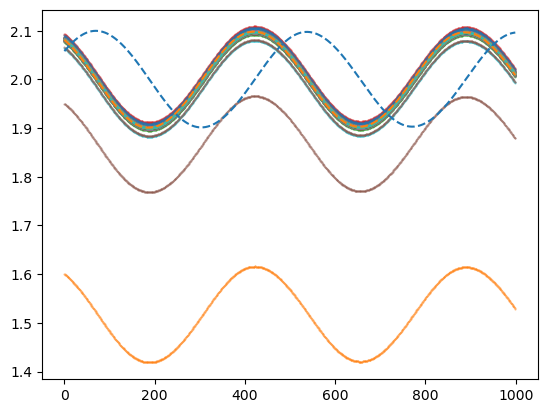

In [549]:
plt.plot( ((X[::2,:1000].T+ 2) % (2*np.pi)),'.',alpha=0.5, markersize=1)
plt.plot(Upred[0,:1000]+2, '--')
plt.plot(Upred[1,:1000]+2,'--')

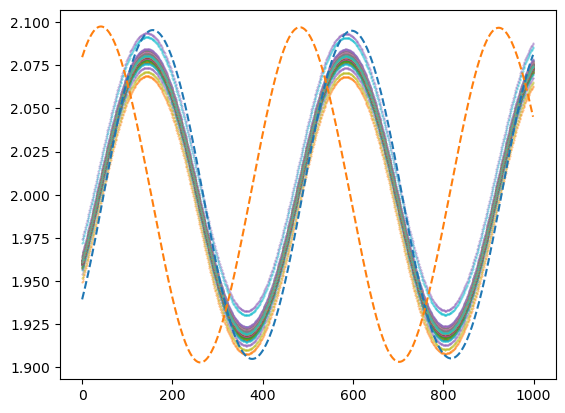

In [435]:
plt.plot( ((X[1::2,:1000].T+ 2) % (2*np.pi)),'.',alpha=0.5, markersize=1)
plt.plot(Upred[0,:1000]+2, '--')
plt.plot(Upred[1,:1000]+2,'--')

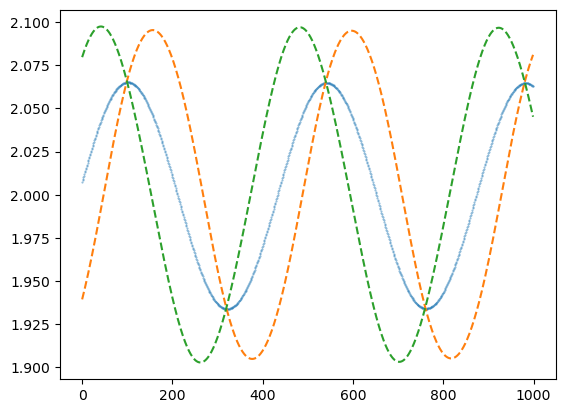

In [436]:
plt.plot( ((X[:,:1000].T+ 2) % (2*np.pi)).mean(axis=1),'.',alpha=0.5, markersize=1)
plt.plot(Upred[0,:1000]+2, '--')
plt.plot(Upred[1,:1000]+2,'--')

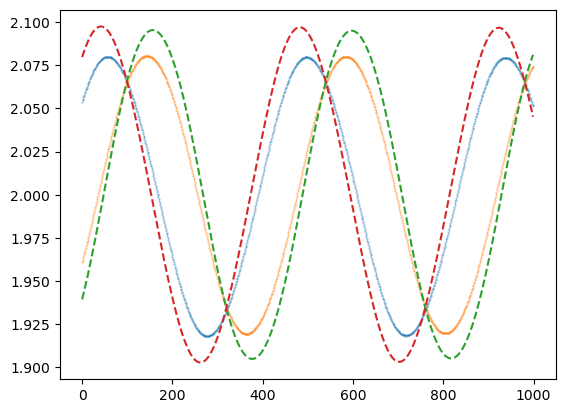

In [437]:
plt.plot( ((X[::2,:1000].T+ 2) % (2*np.pi)).mean(axis=1),'.',alpha=0.5, markersize=1)
plt.plot( ((X[1::2,:1000].T+ 2) % (2*np.pi)).mean(axis=1),'.',alpha=0.5, markersize=1)
plt.plot(Upred[0,:1000]+2, '--')
plt.plot(Upred[1,:1000]+2,'--')

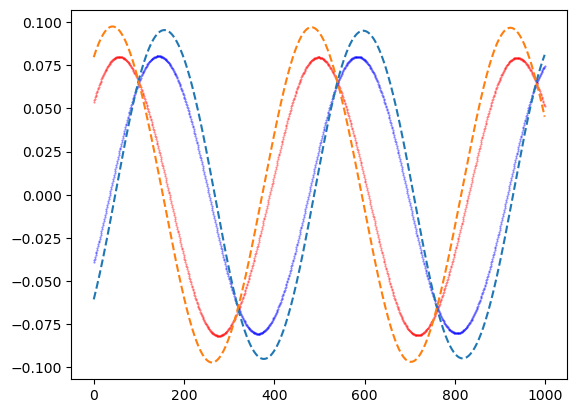

In [438]:
plt.plot( np.sin((X[::2,:1000].T)).mean(axis=1),'.',color='red', alpha=0.5, markersize=1)
plt.plot( np.sin((X[1::2,:1000].T) ).mean(axis=1),'.',color = 'blue', alpha=0.5, markersize=1)
plt.plot(Upred[0,:1000], '--')
plt.plot(Upred[1,:1000],'--')

In [439]:
import cmath

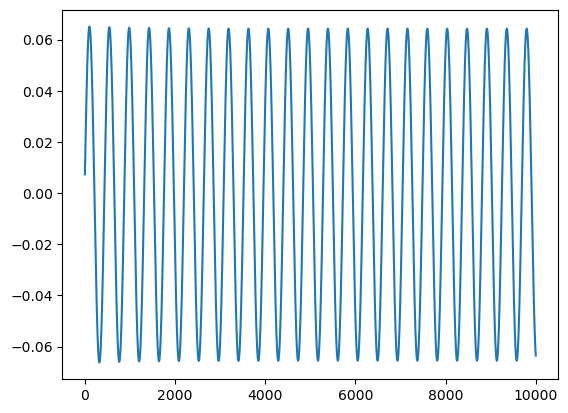

In [440]:
psi_angle = [np.angle(complex(c0,c1)) for c0,c1 in zip(c_order[0,:], c_order[1,:])]
plt.plot(psi_angle)

plt.plot( (Upred[1,:] + Upred[0,:])*(F/K))
plt.plot( ( 2*(F+K)/K -2 ) *np.array(psi_angle))
plt.xlim([0,400])

(0.0, 500.0)

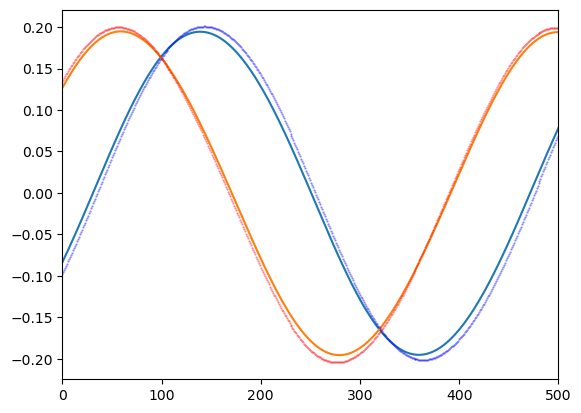

In [441]:
plt.plot(np.sin(np.array(psi_angle)) +(3/2)* np.sin(Upred[0,:]))
plt.plot(np.sin(np.array(psi_angle)) +(3/2)* np.sin(Upred[1,:]))
plt.plot( 2.5*np.sin((X[1::2,:1000].T) ).mean(axis=1),'.',color = 'blue', alpha=0.5, markersize=1)
plt.plot( 2.5*np.sin((X[::2,:1000].T)).mean(axis=1),'.',color='red', alpha=0.5, markersize=1)
plt.xlim([0,500])

In [442]:
F

60

(0.0, 500.0)

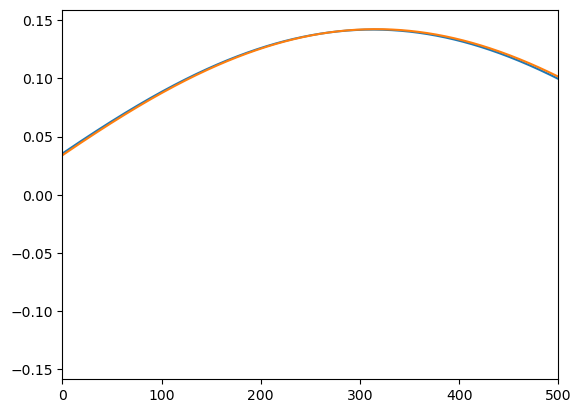

In [130]:
plt.plot( np.sin(Upred[1,:])+ np.sin(Upred[0,:]))
plt.plot(2*np.sin(np.array(psi_angle)))
plt.xlim([0,500])     

(0.0, 500.0)

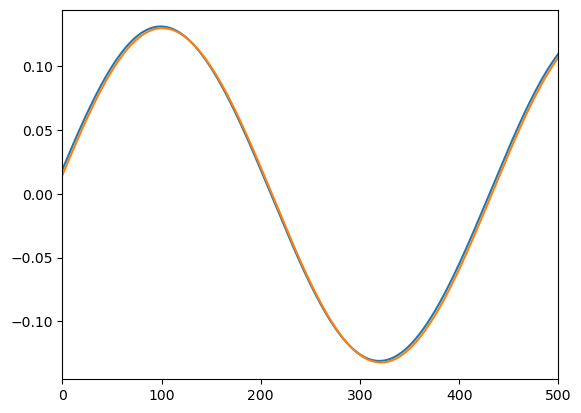

In [444]:
plt.plot( np.sin(Upred[1,:])+ np.sin(Upred[0,:]))
plt.plot(2*np.sin(np.array(psi_angle)))
plt.xlim([0,500])         

(0.0, 500.0)

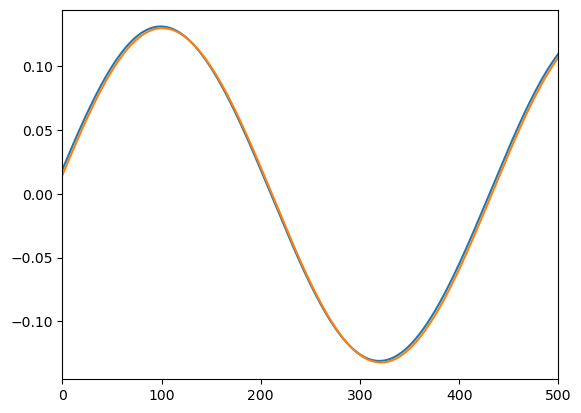

In [445]:
plt.plot( np.sin(Upred[1,:])+ np.sin(Upred[0,:]))
plt.plot(2*np.sin(np.array(psi_angle)))
plt.xlim([0,500])    

(0.0, 400.0)

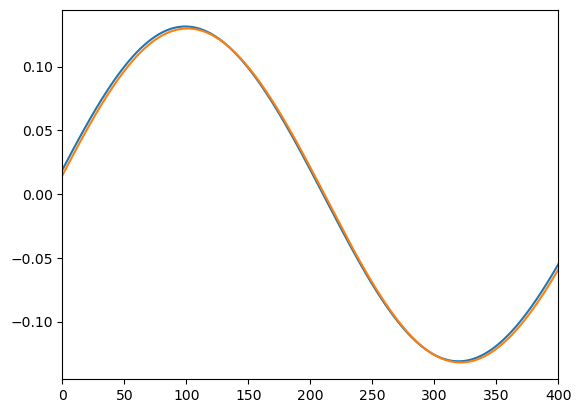

In [450]:
plt.plot( np.sin(Upred[1,:])+ np.sin(Upred[0,:]))
plt.plot(np.sin(2*np.array(psi_angle)))
plt.xlim([0,400])  

(0.0, 400.0)

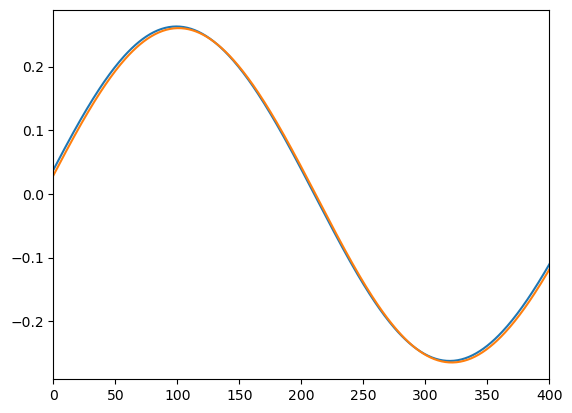

In [451]:
plt.plot( (Upred[1,:] + Upred[0,:])*(F/K))
plt.plot( ( 2*(F+K)/K -2 ) *np.array(psi_angle))
plt.xlim([0,400])

In [95]:
h

0.005

In [96]:
np.arange(5_000,Upred.shape[1])*h

array([25.   , 25.005, 25.01 , ..., 49.985, 49.99 , 49.995])

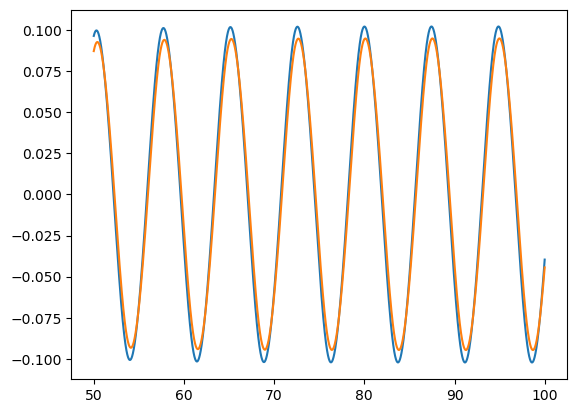

In [32]:
psi_angle = [np.angle(complex(c0,c1)) for c0,c1 in zip(c_even[0,:], c_even[1,:])]
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h,Upred[1,:])
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h,np.sin(psi_angle))

psi_angle = [np.angle(complex(c0,c1)) for c0,c1 in zip(c_odd[0,:], c_odd[1,:])]
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h,Upred[0,:])
plt.plot(np.arange(10_000,10_000+Upred.shape[1])*h,np.sin(psi_angle))


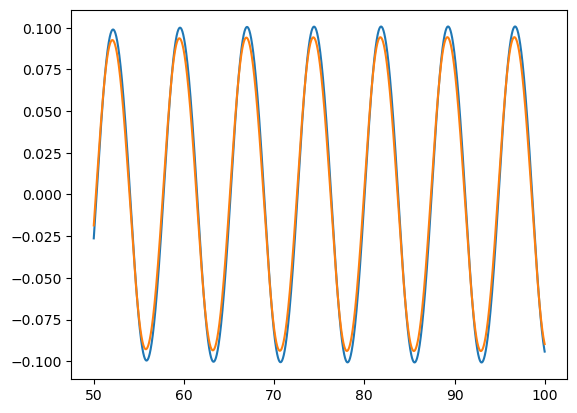

(0.0, 500.0)

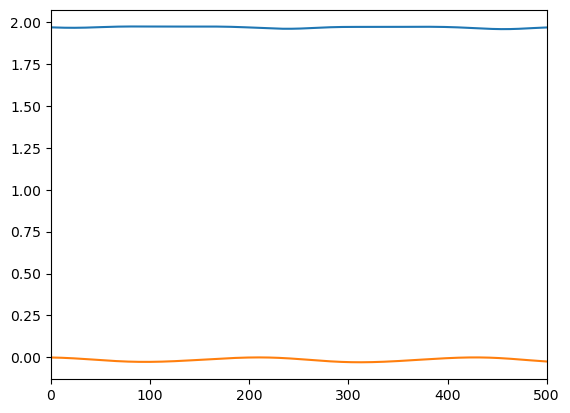

In [55]:
plt.plot(np.cos(Upred[0,:])+np.cos(Upred[1,:]))
plt.plot(np.cos(np.array(psi_angle))*2-2)
plt.xlim([0,500])   

TypeError: multiply() takes from 2 to 3 positional arguments but 1 were given

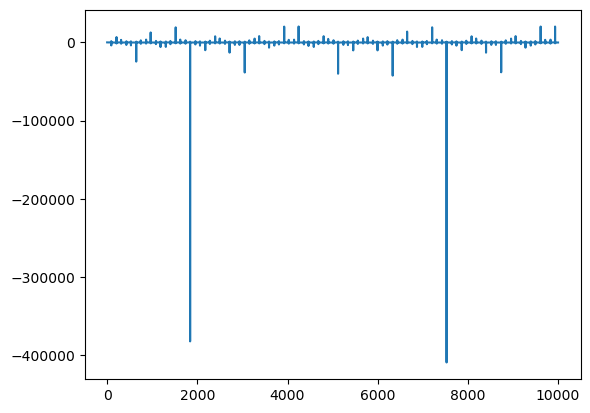

In [51]:
plt.plot(  (np.cos(Upred[0,:])-np.cos(Upred[1,:]))**(-1)) ,np.multiply( np.cos(np.array(psi_angle)) )


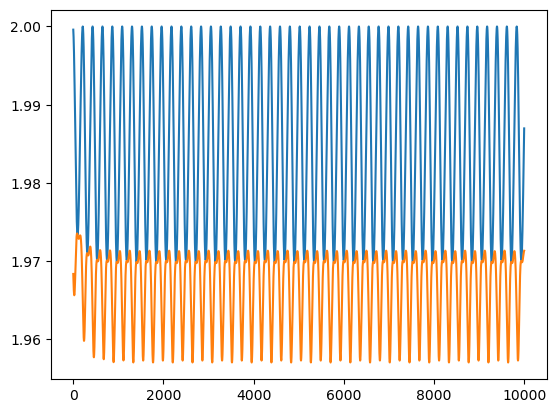

In [45]:
plt.plot(  np.cos(np.array(psi_angle))*2)
plt.plot(np.cos(Upred[0,:])+np.cos(Upred[1,:]))

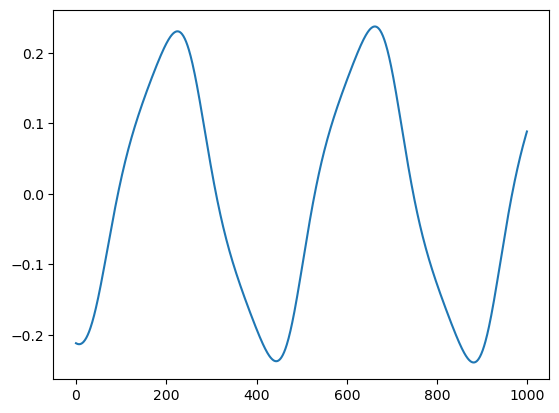

In [40]:
 plt.plot( (np.sin(X[1::2,:1000].T)  - np.sin(X[0::2,:1000].T)).mean(axis=1) )

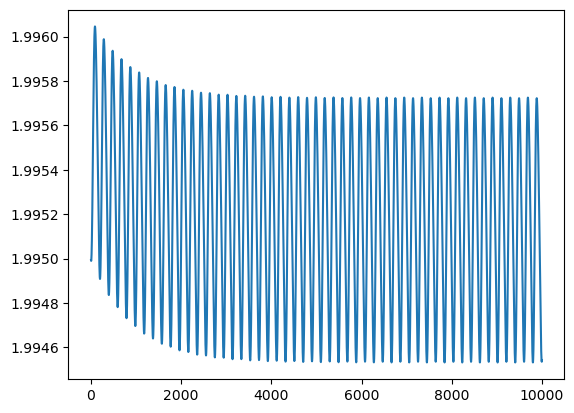

In [623]:
plt.plot(np.cos(Upred[1,:])+ np.cos(Upred[0,:]))

(0.0, 200.0)

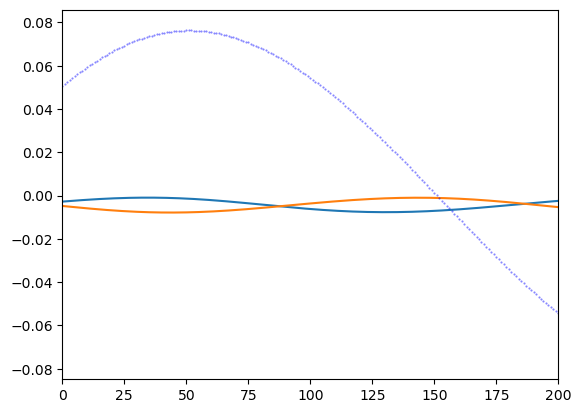

In [622]:
plt.plot(np.cos(np.array(psi_angle)) +(3/2)* np.cos(Upred[0,:])-2.5)
plt.plot(np.cos(np.array(psi_angle)) +(3/2)* np.cos(Upred[1,:])-2.5)
plt.plot( np.sin((X[0::2,:1000].T)).mean(axis=1),'.',color = 'blue', alpha=0.5, markersize=1)
#plt.plot(np.cos((X[1::2,:1000].T)).mean(axis=1)-1,'.',color='red', alpha=0.5, markersize=1)
plt.xlim([0,200])

In [597]:
np.mean(np.cos(np.array(psi_angle)) +(3/2)* np.cos(Upred[0,:]))

2.495354829783524

(0.0, 1000.0)

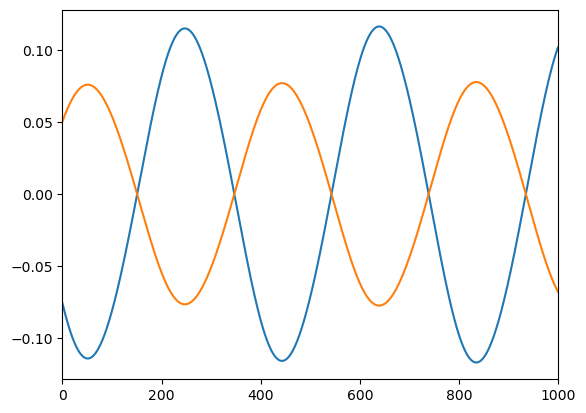

In [554]:
plt.plot((np.multiply(np.cos(X[0,:1000]), np.sin((X[::2,:1000].T) ).mean(axis=1)) - (5/2)* np.sin((X[0,:1000].T))))
plt.plot(np.sin(X[0,:1000]))
plt.xlim([0,1000])

In [550]:
w[0]

0.0015456568342349145

In [568]:
Wout

array([[-1.53817331e-05, -6.21321935e-04,  2.64964217e-03, ...,
         2.64387923e-03, -6.22159259e-04,  2.64988225e-03],
       [-1.61035764e-04,  2.68952615e-03, -7.11569547e-04, ...,
        -7.06997485e-04,  2.69166937e-03, -7.11761140e-04]])

In [567]:
(10/(3*1000))-(2/(3*1000))

0.002666666666666667

In [566]:
-(2/(3*1000))

-0.0006666666666666666

(0.0, 1000.0)

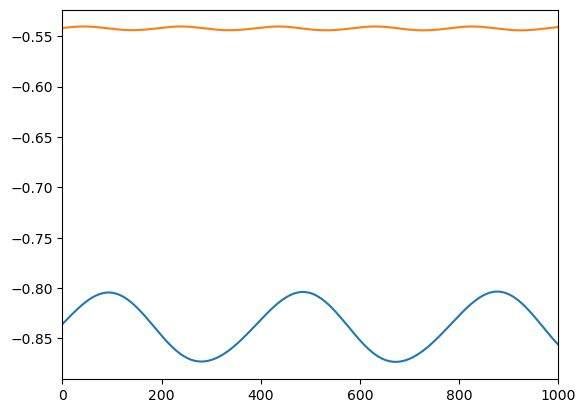

In [544]:
plt.plot(np.sin(np.array(psi_angle) - np.cos(Upred[0,:])))
plt.plot(-np.cos(np.cos(Upred[0,:])))

plt.xlim([0,1000])